In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Set visual style
sns.set_style("whitegrid")

# Load the dataset

In [4]:

df = pd.read_csv('Uber.csv')

# Initial Inspection

In [5]:
print("Dataset Shape:", df.shape)

Dataset Shape: (1141, 17)


In [6]:
df.head(5)

,start_date,start_hour,start_minute,end_date,end_hour,end_minute,month,year,CATEGORY,START,STOP,MILES,PURPOSE,duration,speed,day,day_time
0,2016-01-01,21.0,11.0,2016-01-01,21.0,17.0,Jan,2016,Business,Fort Pierce,Fort Pierce,8.207634,Meal/Entertain,6.0,82.076340,Friday,Evening
1,2016-01-02,1.0,25.0,2016-01-02,1.0,37.0,Jan,2016,Business,Fort Pierce,Fort Pierce,8.046700,Meal/Entertain,12.0,40.233500,Saturday,Night
2,2016-01-02,20.0,25.0,2016-01-02,20.0,38.0,Jan,2016,Business,Fort Pierce,Fort Pierce,7.724832,Errand/Supplies,13.0,35.653071,Saturday,Evening
3,2016-01-05,17.0,31.0,2016-01-05,17.0,45.0,Jan,2016,Business,Fort Pierce,Fort Pierce,7.563898,Meeting,14.0,32.416706,Tuesday,Afternoon
4,2016-01-06,14.0,42.0,2016-01-06,15.0,49.0,Jan,2016,Business,Fort Pierce,West Palm Beach,102.514958,Customer Visit,67.0,91.804440,Wednesday,Afternoon


In [7]:
print(df.isnull().sum())


start_date      0
start_hour      0
start_minute    0
end_date        0
end_hour        0
end_minute      0
month           0
year            0
CATEGORY        0
START           0
STOP            0
MILES           0
PURPOSE         0
duration        0
speed           0
day             0
day_time        0
dtype: int64


# Step 2: Data Cleaning

In [8]:
# 1. Convert Date columns to datetime objects
df['start_date'] = pd.to_datetime(df['start_date'])
df['end_date'] = pd.to_datetime(df['end_date'])

In [9]:
# 2. Check for and remove duplicates
print(f"Duplicates found: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)

Duplicates found: 1


In [10]:
# 3. Handle anomalies
df = df[df['duration'] > 0]
df = df[df['speed'] != np.inf]

print("Cleaned Dataset Shape:", df.shape)

Cleaned Dataset Shape: (1136, 17)


# Step 3: Feature Engineering

In [11]:
# Trip Category by Length
def categorize_trip(miles):
    if miles <= 5:
        return 'Short'
    elif miles <= 15:
        return 'Medium'
    else:
        return 'Long'

df['Trip_Size'] = df['MILES'].apply(categorize_trip)

In [12]:
df['Trip_Size']

0       Medium
1       Medium
2       Medium
3       Medium
4         Long
         ...  
1136     Short
1137    Medium
1138      Long
1139    Medium
1140      Long
Name: Trip_Size, Length: 1136, dtype: object

In [13]:
# 2. Extract Hour and Weekday (if not already present or for verification)
df['start_hour'] = df['start_date'].dt.hour
df['weekday'] = df['start_date'].dt.day_name()

print(df[['MILES', 'Trip_Size', 'weekday']].head())

        MILES Trip_Size    weekday
0    8.207634    Medium     Friday
1    8.046700    Medium   Saturday
2    7.724832    Medium   Saturday
3    7.563898    Medium    Tuesday
4  102.514958      Long  Wednesday


# Step 4: Exploratory Data Analysis (EDA)

In [14]:
# Summary Statistics for numerical columns
print("\nDescriptive Statistics:")
print(df[['MILES', 'duration', 'speed']].describe())


Descriptive Statistics:
             MILES     duration        speed
count  1136.000000  1136.000000  1136.000000
mean     16.247251    22.757042    42.959515
std      31.867681    25.085667    69.824080
min       0.804670     1.000000     6.304357
25%       4.506152    10.000000    23.889294
50%       9.495106    16.000000    33.618031
75%      16.737136    28.000000    45.646735
max     499.378202   330.000000  1458.062040


In [15]:
# Analyze the 'CATEGORY' column (Business vs Personal)
category_counts = df['CATEGORY'].value_counts()
print("\nTrips by Category:")
print(category_counts)


Trips by Category:
CATEGORY
Business    1061
Personal      75
Name: count, dtype: int64


In [16]:
# Analyze the 'PURPOSE' of trips
purpose_counts = df['PURPOSE'].value_counts()
print("\nTop 5 Trip Purposes:")
print(purpose_counts.head())


Top 5 Trip Purposes:
PURPOSE
Meeting            294
Meal/Entertain     245
Temporary Site     191
Errand/Supplies    173
Customer Visit     155
Name: count, dtype: int64


# Step 5: Data Visualization

# A. Distribution of Trip Miles (Histogram)

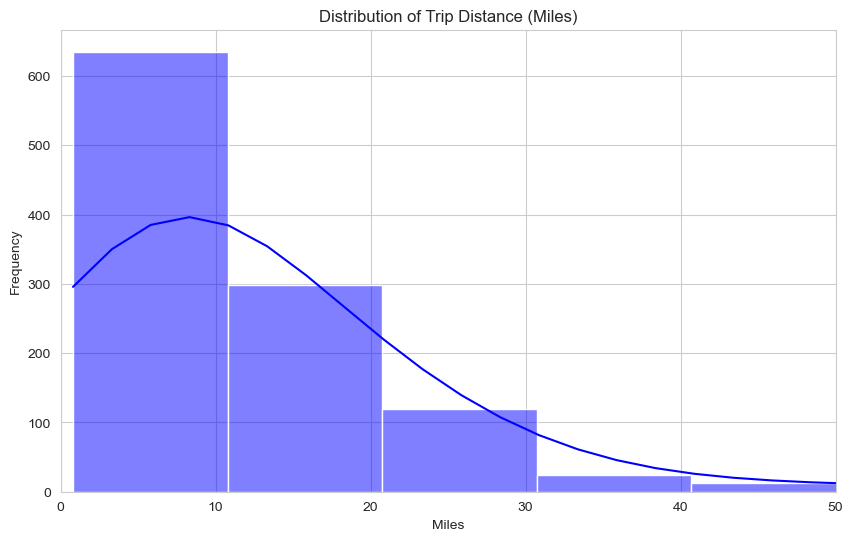

In [17]:
plt.figure(figsize=(10, 6))
sns.histplot(df['MILES'], bins=50, kde=True, color='blue')
plt.title('Distribution of Trip Distance (Miles)')
plt.xlabel('Miles')
plt.ylabel('Frequency')
plt.xlim(0, 50) # Limit x-axis to zoom in on common trips
plt.show()


# B. Count of Trips by Purpose (Count Plot)

C:\Users\ayush\AppData\Local\Temp\ipykernel_22280\816187264.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='PURPOSE', data=df, order=df['PURPOSE'].value_counts().index, palette='viridis')


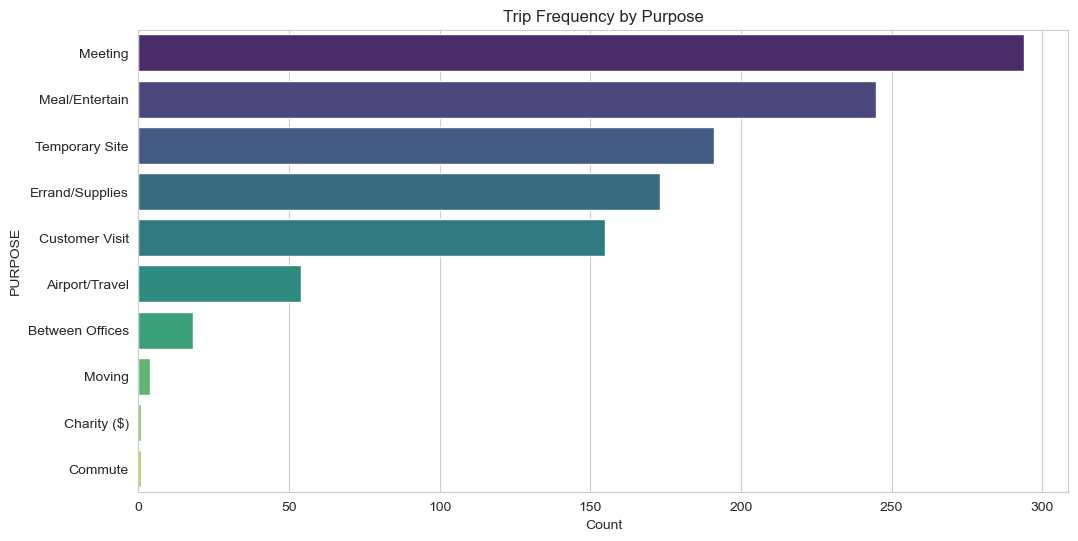

In [18]:
plt.figure(figsize=(12, 6))
sns.countplot(y='PURPOSE', data=df, order=df['PURPOSE'].value_counts().index, palette='viridis')
plt.title('Trip Frequency by Purpose')
plt.xlabel('Count')
plt.show()


# C. Business vs Personal (Pie chart)

Text(0.5, 1.0, 'Business vs Personal')

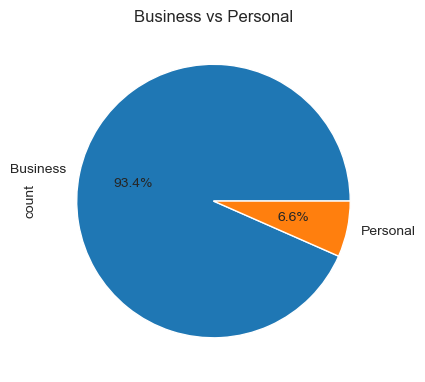

In [19]:
# Business vs Personal (Pie chart)
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
df['CATEGORY'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Business vs Personal')

# D. Trips by Time of Day (Bar Chart)

C:\Users\ayush\AppData\Local\Temp\ipykernel_22280\2139414972.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='day_time', data=df, order=['Morning', 'Afternoon', 'Evening', 'Night'], palette='magma')


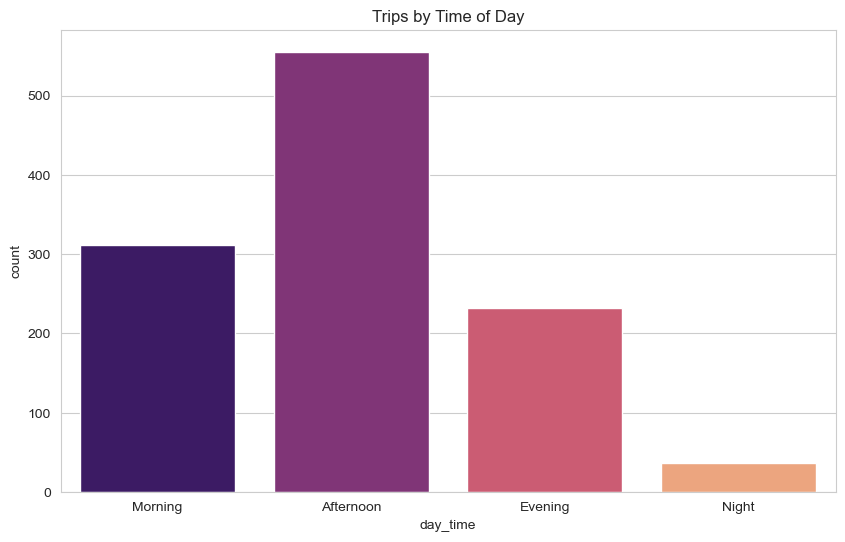

In [20]:
plt.figure(figsize=(10, 6))
sns.countplot(x='day_time', data=df, order=['Morning', 'Afternoon', 'Evening', 'Night'], palette='magma')
plt.title('Trips by Time of Day')
plt.show()


# E. Correlation Heatmap

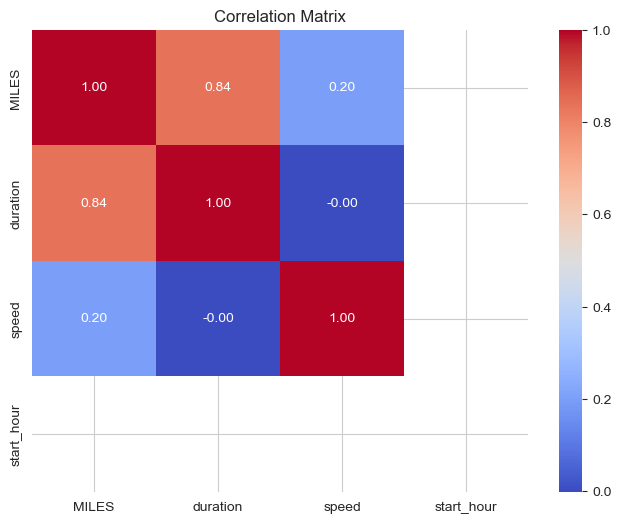

In [21]:
plt.figure(figsize=(8, 6))
corr = df[['MILES', 'duration', 'speed', 'start_hour']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()
